In [22]:
import pandas as pd
data=pd.read_csv("D:\\covid data\\covid_19.csv")
cols = ["Cases", "Recovered", "Deaths", "Tests", "population"]

for col in cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")
remove_rows = [
    "All",
    "Asia",
    "Europe",
    "Africa",
    "Oceania",
    "North-America",
    "South-America"
]
data = data[~data["country"].isin(remove_rows)]

data.head()


,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


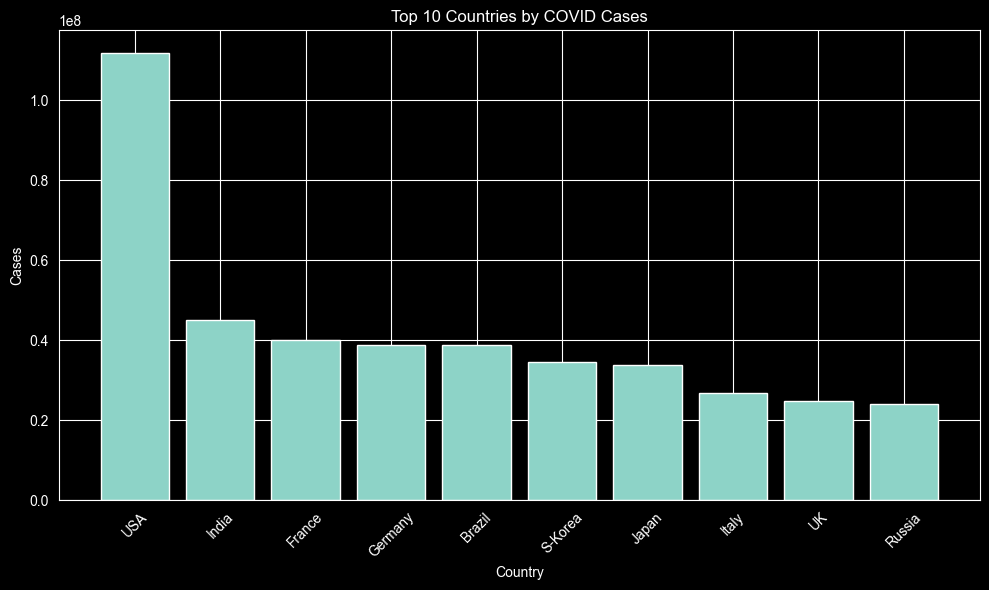

In [24]:
import matplotlib.pyplot as plt
top10 = data.nlargest(10, "Cases")
plt.figure(figsize=(10,6))
plt.bar(top10["country"], top10["Cases"])
plt.title("Top 10 Countries by COVID Cases")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

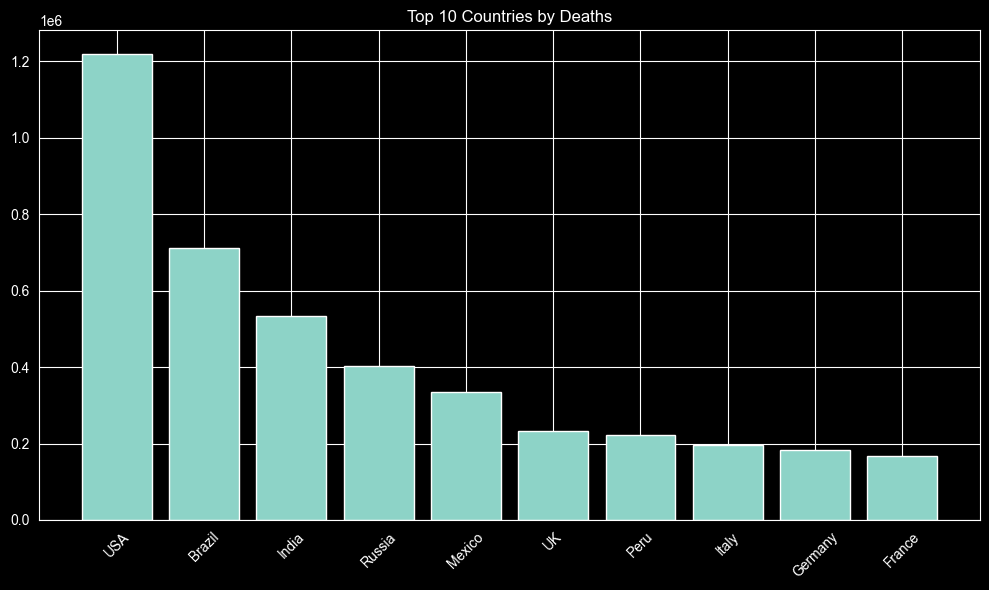

In [26]:
top10_deaths = data.nlargest(10, "Deaths")

plt.figure(figsize=(10,6))
plt.bar(top10_deaths["country"],
        top10_deaths["Deaths"])

plt.title("Top 10 Countries by Deaths")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
data["Death_Rate"] = (
    data["Deaths"] / data["Cases"]
) * 100

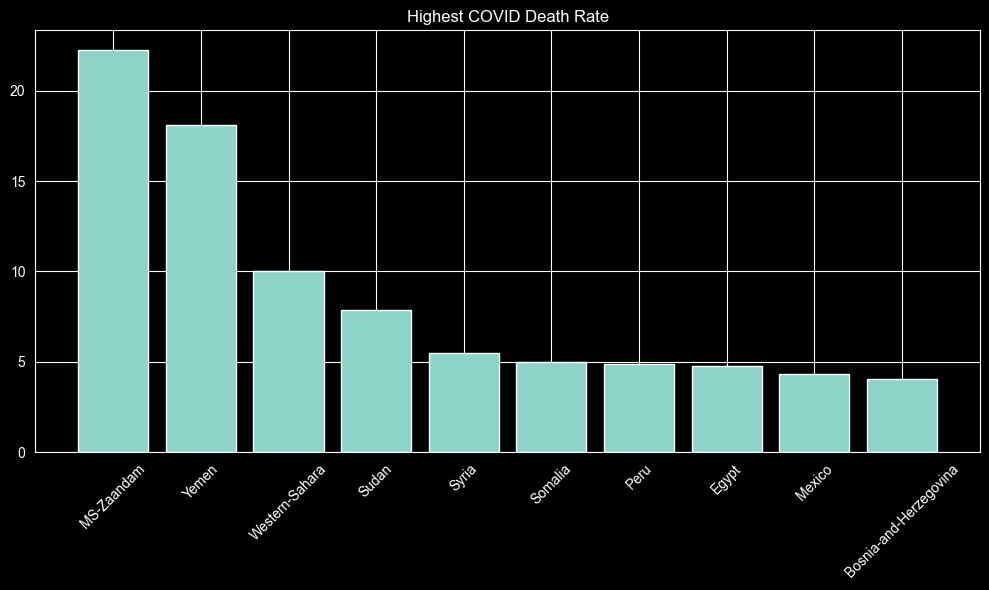

In [30]:
death_rate = data.nlargest(10, "Death_Rate")

plt.figure(figsize=(10,6))
plt.bar(death_rate["country"],
        death_rate["Death_Rate"])

plt.title("Highest COVID Death Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
#recovery rate analysis
data["Recovery_Rate"] = (
    data["Recovered"] / data["Cases"]
) * 100

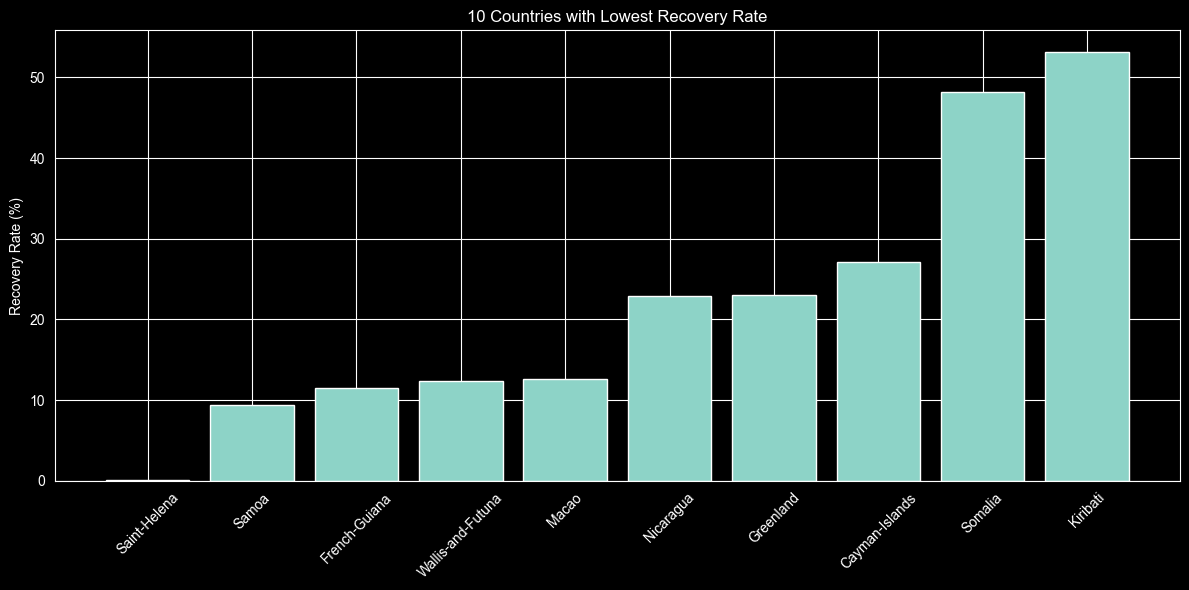

In [41]:
lowest_recovery = data.nsmallest(10, "Recovery_Rate")
plt.figure(figsize=(12,6))
plt.bar(
    lowest_recovery["country"],
    lowest_recovery["Recovery_Rate"]
)

plt.title("10 Countries with Lowest Recovery Rate")
plt.ylabel("Recovery Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [42]:
#cases per million population
data["Cases_Per_Million"] = (
    data["Cases"] / data["population"]
) * 1000000

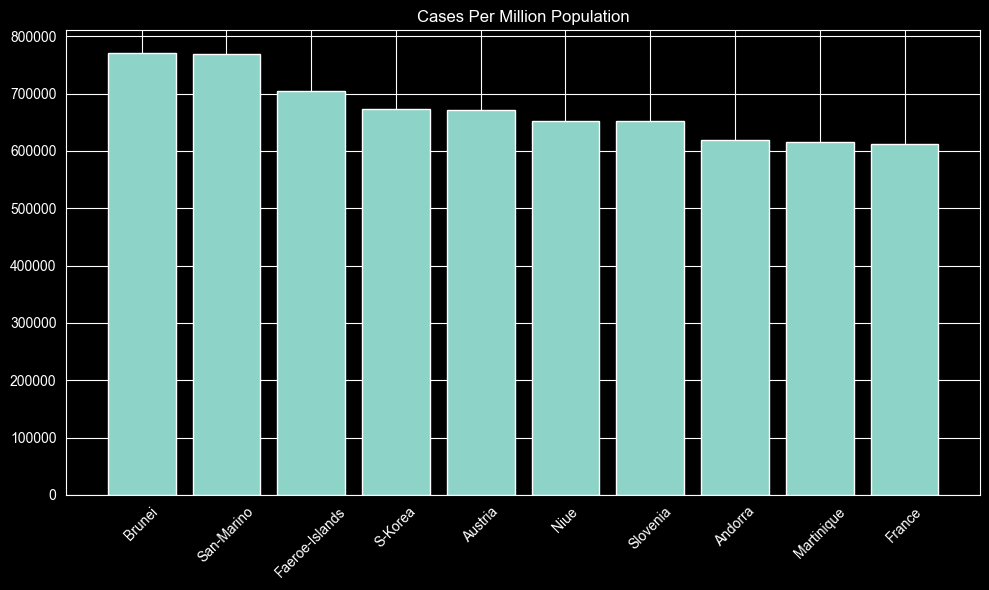

In [43]:
top_cases_pm = data.nlargest(
    10,
    "Cases_Per_Million"
)

plt.figure(figsize=(10,6))
plt.bar(top_cases_pm["country"],
        top_cases_pm["Cases_Per_Million"])

plt.title("Cases Per Million Population")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

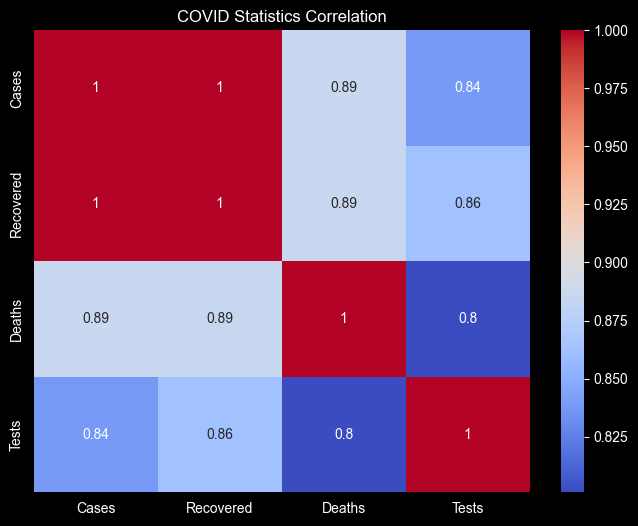

In [45]:
import seaborn as sns

cols = [
    "Cases",
    "Recovered",
    "Deaths",
    "Tests"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    data[cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("COVID Statistics Correlation")

plt.show()